In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,  classification_report
)

In [2]:
tsla  = pd.read_csv('../data/tsla_features.csv',  parse_dates=['date'], index_col='date').sort_index()

In [3]:
tsla.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,-0.013938,-0.013273,14.863905,14.497746,...,0.005838,1,1,0,Winter,0,17.790001,0,0,-0.057681
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041,-0.077825,14.760286,14.436762,...,0.025016,1,1,0,Winter,0,19.920000,0,1,-0.037508
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664,-0.063932,14.655714,14.382794,...,-0.009262,1,1,0,Winter,0,21.120001,0,0,-0.033273
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562,-0.050758,14.495047,14.342286,...,-0.015418,1,1,0,Winter,0,19.309999,0,0,-0.086561
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564,-0.053010,14.351333,14.330413,...,0.000810,1,1,0,Winter,0,17.010000,0,0,-0.089023


In [4]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'month', 'is_earnings_week',
    'vix', 'is_major_event'
]
TARGET_CLS = 'target_direction'

In [5]:
tsla_cls  = tsla[FEATURES + [TARGET_CLS]].dropna().copy()

print(tsla_cls.shape)

(2515, 20)


In [6]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    """
    Generates (train_idx, test_idx) pairs for walk-forward validation.
    embargo = gap between train end and test start to prevent leakage
    from lagged features (lag_return_5, weekly_return, volatility_20 etc.)
    
    Fold 1: Train [0 → 62]  Gap [63 → 67]  Test [68 → 109]
    Fold 2: Train [42 → 104] Gap [105 → 109] Test [110 → 151]
    """
    splits = []
    n = len(df)
    start = 0

    while start + train_window + embargo + test_window <= n:
        train_start = start
        train_end   = start + train_window

        test_start  = train_end + embargo
        test_end    = test_start + test_window

        train_idx = list(range(train_start, train_end))
        test_idx  = list(range(test_start, test_end))

        splits.append((train_idx, test_idx))

        
        start += test_window

    return splits



In [7]:
tsla_folds = walk_forward_splits(tsla_cls, train_window = 189)
print("TSLA folds:", len(tsla_folds))

TSLA folds: 55


In [8]:
fold_scores = []
tsla_actual, tsla_pred = [], []
tsla_probs = []

In [9]:
all_importances = []

In [10]:
for i, (train_idx, test_idx) in enumerate(tsla_folds):
    X_train = tsla_cls.iloc[train_idx][FEATURES]
    y_train = tsla_cls.iloc[train_idx][TARGET_CLS]
    X_test  = tsla_cls.iloc[test_idx][FEATURES]
    y_test  = tsla_cls.iloc[test_idx][TARGET_CLS]

    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

   
    y_p = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

   
    cm = confusion_matrix(y_test, y_p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fold_scores.append({
        'accuracy': accuracy_score(y_test, y_p),
        'f1': f1_score(y_test, y_p, zero_division=0),
        'precision': precision_score(y_test, y_p, zero_division=0),
        'recall': recall_score(y_test, y_p, zero_division=0),
        'specificity': spec
    })

    tsla_actual.extend(y_test)
    tsla_pred.extend(y_p)
    tsla_probs.extend(y_prob)
    all_importances.append(rf.feature_importances_)

In [11]:
results_df = pd.DataFrame(fold_scores)
results_df

,accuracy,f1,precision,recall,specificity
0,0.547619,0.627451,0.533333,0.761905,0.333333
1,0.380952,0.409091,0.360000,0.473684,0.304348
2,0.452381,0.303030,1.000000,0.178571,1.000000
3,0.428571,0.500000,0.444444,0.571429,0.285714
4,0.547619,0.424242,0.538462,0.350000,0.727273
5,0.547619,0.577778,0.500000,0.684211,0.434783
6,0.404762,0.358974,0.333333,0.388889,0.416667
7,0.428571,0.250000,0.666667,0.153846,0.875000
8,0.476190,0.500000,0.578947,0.440000,0.529412
9,0.428571,0.454545,0.476190,0.434783,0.421053


In [12]:

prob_df = pd.DataFrame({
    'actual': tsla_actual,
    'prob_up': tsla_probs

})

high_conviction_up = prob_df[prob_df['prob_up'] > 0.55]
high_conviction_down = prob_df[prob_df['prob_up'] < 0.45]

acc_up = (high_conviction_up['actual'] == 1).mean()
acc_down = (high_conviction_down['actual'] == 0).mean()

print(f"Accuracy when Prob > 0.55 (UP): {acc_up:.4f} (Samples: {len(high_conviction_up)})")
print(f"Accuracy when Prob < 0.45 (DOWN): {acc_down:.4f} (Samples: {len(high_conviction_down)})")

Accuracy when Prob > 0.55 (UP): 0.5012 (Samples: 802)
Accuracy when Prob < 0.45 (DOWN): 0.4503 (Samples: 735)


In [13]:
results_df.describe()

,accuracy,f1,precision,recall,specificity
count,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.482684,0.472783,0.520801,0.493602,0.496463
std,0.074937,0.135497,0.135606,0.207545,0.229906
min,0.357143,0.133333,0.333333,0.080000,0.040000
25%,0.428571,0.404545,0.423274,0.333333,0.315789
50%,0.476190,0.470588,0.500000,0.500000,0.478261
75%,0.547619,0.563310,0.579796,0.650000,0.633971
max,0.642857,0.750000,1.000000,0.941176,1.000000


In [14]:
avg_importance = np.mean(all_importances, axis=0)
feat_imp = pd.Series(avg_importance, index=FEATURES).sort_values(ascending=False)
feat_imp

volume_change       0.065116
lag_return_5        0.064720
volume_ratio        0.064381
lag_return_3        0.064170
vix                 0.061753
daily_range         0.061486
lag_return_1        0.061337
ma_cross            0.061259
daily_return        0.060790
volatility_20       0.059379
volatility_7        0.059174
macd_hist           0.058783
rsi_14              0.057719
weekly_return       0.057645
bb_position         0.056594
dist_from_ma21      0.051099
month               0.026675
is_earnings_week    0.006419
is_major_event      0.001502
dtype: float64

In [15]:
print(classification_report(tsla_actual, tsla_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.46      0.48      0.47      1107
           1       0.50      0.48      0.49      1203

    accuracy                           0.48      2310
   macro avg       0.48      0.48      0.48      2310
weighted avg       0.48      0.48      0.48      2310



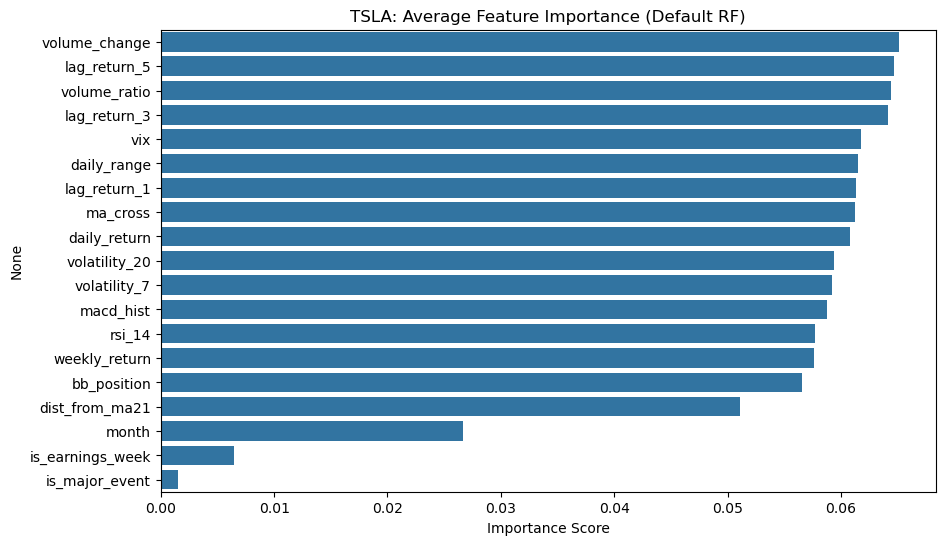

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("TSLA: Average Feature Importance (Default RF)")
plt.xlabel("Importance Score")
plt.show()

In [17]:
from itertools import product

n_estimators_values     = [100, 200, 500]
max_depth_values        = [4, 6, 8, 10, None]
min_samples_leaf_values = [1, 5, 10, 20]
max_features_values     = ['sqrt', 'log2']

combos = list(product(n_estimators_values, max_depth_values, min_samples_leaf_values, max_features_values))
print(f'Grid: {len(n_estimators_values)} n_estimators x {len(max_depth_values)} max_depth x {len(min_samples_leaf_values)} min_samples_leaf x {len(max_features_values)} max_features = {len(combos)} combinations')
print(f'Folds per combo: {len(tsla_folds)}')
print(f'Total RF fits: {len(combos) * len(tsla_folds)}')

Grid: 3 n_estimators x 5 max_depth x 4 min_samples_leaf x 2 max_features = 120 combinations
Folds per combo: 55
Total RF fits: 6600


In [18]:
grid_results = []

for n_est, max_d, min_leaf, max_feat in combos:
    fold_f1s, fold_accs, fold_precs, fold_recs, fold_specs = [], [], [], [], []

    for train_idx, test_idx in tsla_folds:
        X_train = tsla_cls.iloc[train_idx][FEATURES]
        y_train = tsla_cls.iloc[train_idx][TARGET_CLS]
        X_test  = tsla_cls.iloc[test_idx][FEATURES]
        y_test  = tsla_cls.iloc[test_idx][TARGET_CLS]

        rf = RandomForestClassifier(
            n_estimators=n_est, max_depth=max_d, min_samples_leaf=min_leaf,
            max_features=max_feat, class_weight='balanced', random_state=42, n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        fold_f1s.append(f1_score(y_test, y_pred, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_pred))
        fold_precs.append(precision_score(y_test, y_pred, zero_division=0))
        fold_recs.append(recall_score(y_test, y_pred, zero_division=0))

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        fold_specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    grid_results.append({
        'n_estimators': n_est, 'max_depth': max_d, 'min_samples_leaf': min_leaf,
        'max_features': max_feat, 'f1': np.mean(fold_f1s), 'accuracy': np.mean(fold_accs),
        'precision': np.mean(fold_precs), 'recall': np.mean(fold_recs), 'specificity': np.mean(fold_specs),
    })
    print(f'  n_est={n_est:>3}  depth={str(max_d):<5}  min_leaf={min_leaf:<3}  max_feat={max_feat:<5}  '
          f'F1={np.mean(fold_f1s):.3f}  acc={np.mean(fold_accs):.3f}  '
          f'prec={np.mean(fold_precs):.3f}  rec={np.mean(fold_recs):.3f}  spec={np.mean(fold_specs):.3f}')

rf_grid_df = pd.DataFrame(grid_results)

  n_est=100  depth=4      min_leaf=1    max_feat=sqrt   F1=0.452  acc=0.483  prec=0.509  rec=0.452  spec=0.541
  n_est=100  depth=4      min_leaf=1    max_feat=log2   F1=0.452  acc=0.483  prec=0.509  rec=0.452  spec=0.541
  n_est=100  depth=4      min_leaf=5    max_feat=sqrt   F1=0.454  acc=0.494  prec=0.514  rec=0.455  spec=0.555
  n_est=100  depth=4      min_leaf=5    max_feat=log2   F1=0.454  acc=0.494  prec=0.514  rec=0.455  spec=0.555
  n_est=100  depth=4      min_leaf=10   max_feat=sqrt   F1=0.456  acc=0.492  prec=0.508  rec=0.467  spec=0.544
  n_est=100  depth=4      min_leaf=10   max_feat=log2   F1=0.456  acc=0.492  prec=0.508  rec=0.467  spec=0.544
  n_est=100  depth=4      min_leaf=20   max_feat=sqrt   F1=0.456  acc=0.498  prec=0.514  rec=0.468  spec=0.559
  n_est=100  depth=4      min_leaf=20   max_feat=log2   F1=0.456  acc=0.498  prec=0.514  rec=0.468  spec=0.559
  n_est=100  depth=6      min_leaf=1    max_feat=sqrt   F1=0.462  acc=0.481  prec=0.521  rec=0.474  spec=0.512
 

In [19]:
print('Top 5 by F1:')
print(rf_grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('\nTop 5 by Accuracy:')
print(rf_grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('\nTop 5 by Precision:')
print(rf_grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('\nTop 5 by Specificity:')
print(rf_grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nCurrent baseline (n_estimators=100):')
print(rf_grid_df[rf_grid_df['n_estimators'] == 100].to_string(index=False))

Top 5 by F1:
 n_estimators  max_depth  min_samples_leaf max_features       f1  accuracy  precision   recall  specificity
          100       10.0                 1         sqrt 0.481997  0.483983   0.526217 0.508604     0.482076
          100       10.0                 1         log2 0.481997  0.483983   0.526217 0.508604     0.482076
          500       10.0                 1         log2 0.477489  0.482251   0.522962 0.508515     0.481579
          500       10.0                 1         sqrt 0.477489  0.482251   0.522962 0.508515     0.481579
          200       10.0                 1         log2 0.476322  0.480952   0.514750 0.504256     0.483451

Top 5 by Accuracy:
 n_estimators  max_depth  min_samples_leaf max_features       f1  accuracy  precision   recall  specificity
          200        4.0                10         log2 0.458555  0.499567   0.537023 0.464063     0.562507
          200        4.0                10         sqrt 0.458555  0.499567   0.537023 0.464063     0.56